In [ ]:
from pathlib import Path
import yaml

STYLE_PATH = Path("visual-style.yml")

with open(STYLE_PATH, "r", encoding="utf-8") as f:
    STYLE = yaml.safe_load(f)

STYLE["colors"]["palette"]["blue"]["main"]

'#6F93B2'

In [ ]:
from manim import *
from pathlib import Path
import yaml

# Load style
with open("visual-style.yml", "r", encoding="utf-8") as f:
    STYLE = yaml.safe_load(f)

Manim Community v0.20.1

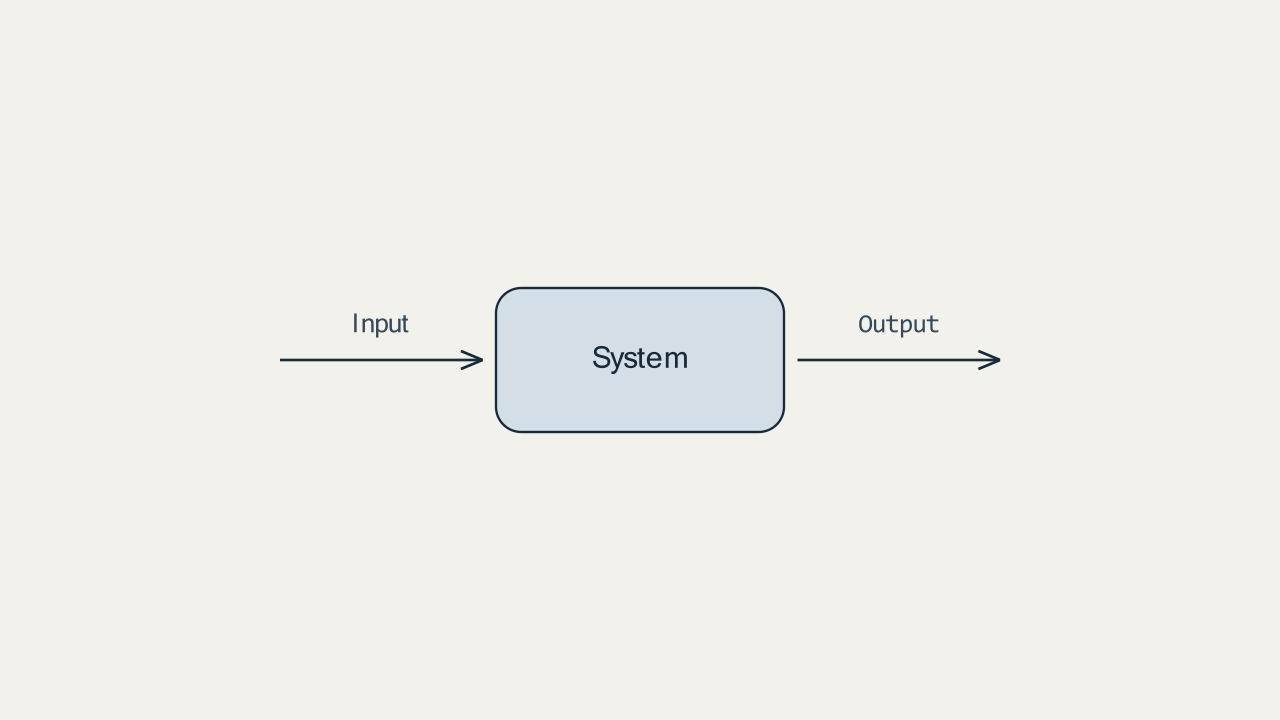

In [ ]:
%%manim -qm -v WARNING SimpleDiagram

class SimpleDiagram(Scene):
    def construct(self):

        self.camera.background_color = STYLE["canvas"]["background"]

        # Main object
        box = RoundedRectangle(
            width=3.2,
            height=1.6,
            corner_radius=STYLE["shapes"]["corners"]["large"],
            stroke_color=STYLE["strokes"]["color"]["primary"],
            stroke_width=STYLE["strokes"]["width"]["normal"],
            fill_color=STYLE["colors"]["palette"]["blue"]["light"],
            fill_opacity=STYLE["shapes"]["fill"]["soft_opacity"],
        )

        # Label
        label = Text(
            "System",
            font=STYLE["typography"]["fonts"]["sans"],
            font_size=STYLE["typography"]["sizes"]["label"],
            color=STYLE["typography"]["color"]["primary"],
        )

        # Input/output arrows
        arrow_style = dict(
            color=STYLE["arrows"]["color"],
            stroke_width=STYLE["arrows"]["stroke_width"],
            tip_length=STYLE["arrows"]["tip"]["length"],
            buff=0.15,
        )

        arrow_in = Arrow(
            LEFT * 4,
            box.get_left(),
            color=STYLE["arrows"]["color"],
            stroke_width=STYLE["arrows"]["stroke_width"],
            tip_length=STYLE["arrows"]["tip"]["length"],
            buff=0.15,
        )

        arrow_out = Arrow(
            box.get_right(),
            RIGHT * 4,
            color=STYLE["arrows"]["color"],
            stroke_width=STYLE["arrows"]["stroke_width"],
            tip_length=STYLE["arrows"]["tip"]["length"],
            buff=0.15,
        )

        input_text = Text(
            "Input",
            font=STYLE["typography"]["fonts"]["sans"],
            font_size=STYLE["typography"]["sizes"]["annotation"],
            color=STYLE["typography"]["color"]["secondary"],
        ).next_to(arrow_in, UP, buff=0.15)

        output_text = Text(
            "Output",
            font=STYLE["typography"]["fonts"]["mono"],
            font_size=STYLE["typography"]["sizes"]["annotation"],
            color=STYLE["typography"]["color"]["secondary"],
        ).next_to(arrow_out, UP, buff=0.15)

        self.add(
            box,
            label,
            arrow_in,
            arrow_out,
            input_text,
            output_text,
        )